# High-dimensional image prediction with latent-space conformal sets
This notebook trains an autoencoder on target images, freezes it, then trains an input-image-to-latent predictor. A held-out calibration split supplies latent residuals; a regularized residual covariance defines Mahalanobis scores, and split conformal quantiles set the prediction radius. The final test split is used only for evaluation.
By default, the notebook downloads Fashion-MNIST and makes paired examples: the target is a real 28x28 clothing image, while the input is a blurred, noisy version. The first 8,000 examples are used so this demo remains manageable; change `MAX_FASHION_IMAGES` to use more. On the first run, TorchVision downloads the dataset into `FASHION_MNIST_ROOT`. For a quick offline run set `DATA_MODE = "synthetic"`. To use your own pairs, set `DATA_MODE = "npz"` and point `DATA_NPZ` at an `.npz` file containing `X` and `Y` arrays shaped `(N, H, W)` or `(N, C, H, W)`. Images are scaled to `[0, 1]`. Adjust latent size and epoch counts for your hardware.
For each requested miscoverage level, the notebook reports latent-set empirical coverage and compares the conformal threshold with a Gaussian chi-square threshold. The chi-square result is a parametric reference, not a conformal guarantee. Covariance shrinkage is used because latent residual dimension can be large relative to calibration sample size. The distribution-free statement is marginal coverage of the latent vector under exchangeability; it does not imply pixelwise coverage after decoding.


In [1]:
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import chi2
SEED = 2026
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_MODE = 'fashion_mnist'  # options: 'fashion_mnist', 'synthetic', 'npz'
DATA_NPZ = 'path/to/paired_images.npz'
FASHION_MNIST_ROOT = './data'
MAX_FASHION_IMAGES = 8000
TRAIN_FRACTION, CAL_FRACTION = 0.60, 0.20
LATENT_DIM = 32
BATCH_SIZE = 64
AE_EPOCHS, PREDICTOR_EPOCHS = 12, 15
ALPHAS = [0.01, 0.05, 0.10, 0.20]
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Device:', DEVICE)


Device: cpu


## 1. Load paired image data and make fixed splits

The autoencoder and latent predictor see training examples only. Calibration residuals are computed after both models are frozen. The test set remains untouched until the final evaluation cell. Do not tune architecture or training choices on the test results.

100%|██████████| 26.4M/26.4M [00:08<00:00, 3.07MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 233kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.42MB/s]


X/Y: (8000, 1, 28, 28) (8000, 1, 28, 28) | train/cal/test: 4800 1600 1600


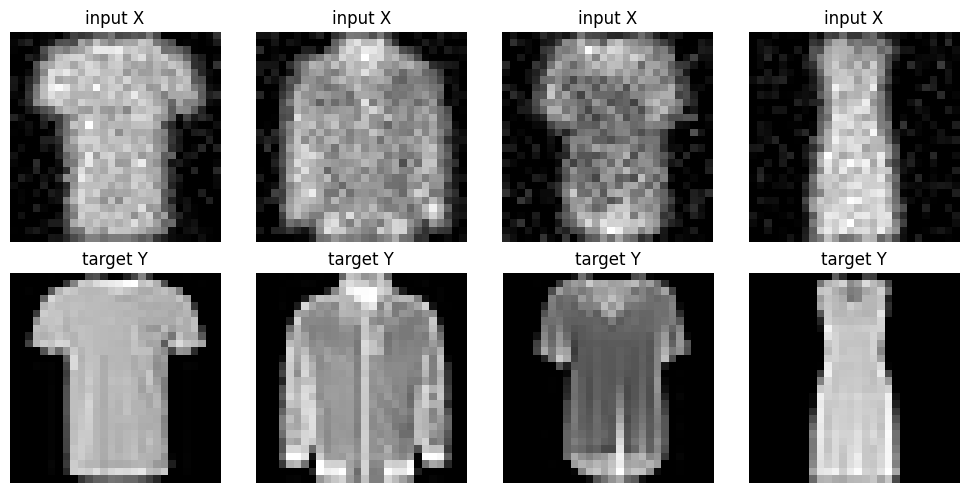

In [2]:
def make_synthetic_pairs(n=2400, side=16, seed=SEED):
    """Small paired image problem: X is blurred/noisy; Y is the clean image."""
    rng = np.random.default_rng(seed)
    grid = np.linspace(-1, 1, side, dtype=np.float32)
    xx, yy = np.meshgrid(grid, grid)
    images = []
    for _ in range(n):
        cx, cy = rng.uniform(-0.45, 0.45, 2)
        sx, sy = rng.uniform(0.12, 0.38, 2)
        angle = rng.uniform(0, np.pi)
        xr = (xx-cx)*np.cos(angle) + (yy-cy)*np.sin(angle)
        yr = -(xx-cx)*np.sin(angle) + (yy-cy)*np.cos(angle)
        image = np.exp(-0.5*((xr/sx)**2 + (yr/sy)**2))
        image += 0.45*np.exp(-((xx+0.4*cy)**2 + (yy-0.3*cx)**2)/0.08)
        image = image / max(image.max(), 1e-6)
        images.append(image.astype(np.float32))
    Y = np.stack(images)[:, None]
    # A simple local blur using a fixed 3x3 averaging kernel.
    y = torch.from_numpy(Y)
    kernel = torch.ones(1, 1, 3, 3) / 9
    X = nn.functional.conv2d(y, kernel, padding=1).numpy()
    X += rng.normal(0, 0.025, X.shape).astype(np.float32)
    return np.clip(X, 0, 1), Y
if DATA_MODE == 'npz':
    data = np.load(DATA_NPZ)
    X, Y = data['X'], data['Y']
elif DATA_MODE == 'fashion_mnist':
    from torchvision.datasets import FashionMNIST
    fashion = FashionMNIST(root=FASHION_MNIST_ROOT, train=True, download=True)
    Y = fashion.data[:MAX_FASHION_IMAGES].numpy().astype(np.float32)[:, None] / 255.0
    # Blur each real target and add independent sensor noise to form its input.
    clean = torch.from_numpy(Y)
    blur_kernel = torch.ones(1, 1, 3, 3) / 9
    X = nn.functional.conv2d(clean, blur_kernel, padding=1).numpy()
    rng_corrupt = np.random.default_rng(SEED + 1)
    X = np.clip(X + rng_corrupt.normal(0, 0.08, X.shape).astype(np.float32), 0, 1)
elif DATA_MODE == 'synthetic':
    X, Y = make_synthetic_pairs()
else:
    raise ValueError('DATA_MODE must be fashion_mnist, synthetic, or npz')
def as_nchw(a):
    a = np.asarray(a, dtype=np.float32)
    if a.ndim == 3: a = a[:, None, :, :]
    if a.ndim != 4: raise ValueError('X and Y must have shape (N,H,W) or (N,C,H,W)')
    if a.max() > 1.0: a = a / 255.0
    return np.clip(a, 0, 1)
X, Y = as_nchw(X), as_nchw(Y)
if X.shape != Y.shape: raise ValueError(f'Paired X and Y shapes must match; got {X.shape} and {Y.shape}')
if X.shape[-2] % 4 or X.shape[-1] % 4: raise ValueError('Image height and width must be divisible by 4')
rng = np.random.default_rng(SEED)
order = rng.permutation(len(X))
n_train = int(TRAIN_FRACTION*len(X)); n_cal = int(CAL_FRACTION*len(X))
idx_train, idx_cal, idx_test = order[:n_train], order[n_train:n_train+n_cal], order[n_train+n_cal:]
def tensor_pair(ids): return (torch.from_numpy(X[ids]), torch.from_numpy(Y[ids]))
train_ds, cal_ds, test_ds = map(tensor_pair, (idx_train, idx_cal, idx_test))
print('X/Y:', X.shape, Y.shape, '| train/cal/test:', len(idx_train), len(idx_cal), len(idx_test))
fig, ax = plt.subplots(2, 4, figsize=(10, 5))
for j in range(4):
    ax[0,j].imshow(X[idx_train[j],0], cmap='gray'); ax[0,j].set_title('input X'); ax[0,j].axis('off')
    ax[1,j].imshow(Y[idx_train[j],0], cmap='gray'); ax[1,j].set_title('target Y'); ax[1,j].axis('off')
plt.tight_layout()


## 2. Train the target autoencoder, then freeze it

The encoder maps each target image to a compact vector, and the decoder reconstructs it. Both are trained only on the training targets. We then freeze both modules; the predictor below learns to estimate the frozen encoder's target representation from the input image.

**What “frozen” means:** after autoencoder training, its encoder and decoder weights are marked non-trainable (`requires_grad=False`) and the autoencoder is put in evaluation mode. Predictor training updates only the separate input-to-latent model. The encoder still converts training targets to latent labels, and the fixed decoder later turns predicted latent vectors back into images.

In [3]:
class ConvAutoencoder(nn.Module):
    def __init__(self, channels, latent_dim):
        super().__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(channels, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(), nn.Flatten())
        flat_dim = 64*(H//4)*(W//4)
        self.to_latent = nn.Linear(flat_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, flat_dim)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, channels, 4, stride=2, padding=1), nn.Sigmoid())
        self.channels, self.height, self.width = channels, H, W
    def encode(self, image): return self.to_latent(self.encoder_conv(image))
    def decode(self, z):
        h = self.from_latent(z).view(-1, 64, self.height//4, self.width//4)
        return self.decoder_conv(h)
    def forward(self, image): return self.decode(self.encode(image))

_, channels, H, W = Y.shape
autoencoder = ConvAutoencoder(channels, LATENT_DIM).to(DEVICE)
train_loader = DataLoader(TensorDataset(train_ds[1]), batch_size=BATCH_SIZE, shuffle=True)
opt = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
for epoch in range(AE_EPOCHS):
    autoencoder.train(); running = 0.0
    for (target,) in train_loader:
        target = target.to(DEVICE); opt.zero_grad()
        loss = nn.functional.mse_loss(autoencoder(target), target)
        loss.backward(); opt.step(); running += loss.item()*len(target)
    print(f'AE epoch {epoch+1:02d}/{AE_EPOCHS}: train MSE={running/len(train_ds[1]):.5f}')
for p in autoencoder.parameters(): p.requires_grad_(False)
autoencoder.eval()
print('Encoder and decoder frozen:', all(not p.requires_grad for p in autoencoder.parameters()))

AE epoch 01/12: train MSE=0.07191
AE epoch 02/12: train MSE=0.02652
AE epoch 03/12: train MSE=0.02130
AE epoch 04/12: train MSE=0.01854
AE epoch 05/12: train MSE=0.01674
AE epoch 06/12: train MSE=0.01535
AE epoch 07/12: train MSE=0.01435
AE epoch 08/12: train MSE=0.01351
AE epoch 09/12: train MSE=0.01285
AE epoch 10/12: train MSE=0.01228
AE epoch 11/12: train MSE=0.01188
AE epoch 12/12: train MSE=0.01142
Encoder and decoder frozen: True


## 3. Train the frozen-encoder latent predictor

The predictor minimizes squared error between its latent estimate $g(X)$ and the frozen encoder representation $E(Y)$. Its outputs are $\\hat z(X)$. The decoder remains frozen and can turn this central latent prediction back into an image.

In [4]:
class LatentPredictor(nn.Module):
    def __init__(self, channels, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64*(H//4)*(W//4), 128), nn.ReLU(),
            nn.Linear(128, latent_dim))
    def forward(self, x): return self.net(x)

predictor = LatentPredictor(channels, LATENT_DIM).to(DEVICE)
pred_loader = DataLoader(TensorDataset(*train_ds), batch_size=BATCH_SIZE, shuffle=True)
opt = torch.optim.Adam(predictor.parameters(), lr=1e-3)
for epoch in range(PREDICTOR_EPOCHS):
    predictor.train(); running = 0.0
    for x, y in pred_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.no_grad(): z_target = autoencoder.encode(y)
        opt.zero_grad(); loss = nn.functional.mse_loss(predictor(x), z_target)
        loss.backward(); opt.step(); running += loss.item()*len(x)
    print(f'Predictor epoch {epoch+1:02d}/{PREDICTOR_EPOCHS}: latent MSE={running/len(train_ds[0]):.5f}')
predictor.eval()

@torch.no_grad()
def collect_latents(dataset):
    loader = DataLoader(TensorDataset(*dataset), batch_size=BATCH_SIZE, shuffle=False)
    z_true, z_pred = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        z_true.append(autoencoder.encode(y).cpu().numpy())
        z_pred.append(predictor(x).cpu().numpy())
    return np.concatenate(z_true), np.concatenate(z_pred)

z_cal, zhat_cal = collect_latents(cal_ds)
res_cal = z_cal - zhat_cal
print('Calibration residual matrix:', res_cal.shape)

Predictor epoch 01/15: latent MSE=4.49744
Predictor epoch 02/15: latent MSE=1.24806
Predictor epoch 03/15: latent MSE=0.66728
Predictor epoch 04/15: latent MSE=0.42239
Predictor epoch 05/15: latent MSE=0.31379
Predictor epoch 06/15: latent MSE=0.24732
Predictor epoch 07/15: latent MSE=0.21284
Predictor epoch 08/15: latent MSE=0.18534
Predictor epoch 09/15: latent MSE=0.16483
Predictor epoch 10/15: latent MSE=0.15587
Predictor epoch 11/15: latent MSE=0.13977
Predictor epoch 12/15: latent MSE=0.13439
Predictor epoch 13/15: latent MSE=0.12531
Predictor epoch 14/15: latent MSE=0.12012
Predictor epoch 15/15: latent MSE=0.11524
Calibration residual matrix: (1600, 32)


## 4. Residual covariance and Mahalanobis calibration scores

Split the calibration partition in two: estimate residual covariance on the first part, then compute calibration scores only on the second part. This separation is needed because fitting the score function on the same examples used to calibrate its quantile can break split conformal validity. Shrink covariance toward its diagonal and add a small ridge to stabilize inversion when latent dimension is high. Use the finite-sample split conformal rank ceil((n_score+1)*(1-alpha)), capped at the largest observed score.

In [5]:
def estimate_shrunk_covariance(residuals, shrinkage=0.10, ridge=1e-5):
    cov = np.cov(residuals, rowvar=False, ddof=1)
    diagonal = np.diag(np.diag(cov))
    cov = (1-shrinkage)*cov + shrinkage*diagonal
    scale = max(float(np.trace(cov)/cov.shape[0]), 1e-8)
    cov += ridge*scale*np.eye(cov.shape[0])
    return cov

# Disjoint examples for covariance fitting and score calibration.
n_cov = max(2, len(res_cal)//2)
res_cov_fit, res_score_cal = res_cal[:n_cov], res_cal[n_cov:]
if len(res_score_cal) == 0: raise ValueError("Need at least 3 calibration examples")
cov = estimate_shrunk_covariance(res_cov_fit)
precision = np.linalg.pinv(cov, hermitian=True)
def mahalanobis_scores(residuals, precision):
    return np.sqrt(np.maximum(np.einsum('bi,ij,bj->b', residuals, precision, residuals), 0))
scores_cal = mahalanobis_scores(res_score_cal, precision)

def split_conformal_quantile(scores, alpha):
    n = len(scores)
    rank = int(np.ceil((n+1)*(1-alpha)))
    if rank > n: return np.inf
    return np.partition(scores, rank-1)[rank-1]

print(f'Covariance shape={cov.shape}, condition number={np.linalg.cond(cov):.2e}')
print(f'Covariance fit n={len(res_cov_fit)}, score calibration n={len(res_score_cal)}')


Covariance shape=(32, 32), condition number=8.08e+00
Covariance fit n=800, score calibration n=800


## 5. Evaluate once on the untouched test split

For each $\\alpha$, compare the conformal ellipsoid to a Gaussian chi-square baseline with the same estimated covariance. Coverage is measured in the learned latent representation: whether the true encoded target lies inside the ellipsoid centered at the predicted latent vector. The conformal threshold uses calibration scores only; the chi-square baseline uses $\\chi^2_d$ quantiles. A finite test set gives an empirical estimate, not an exact coverage guarantee.

In [6]:
z_test, zhat_test = collect_latents(test_ds)
res_test = z_test - zhat_test
scores_test = mahalanobis_scores(res_test, precision)
results = []
for alpha in ALPHAS:
    q_conf = split_conformal_quantile(scores_cal, alpha)
    q_gauss = math.sqrt(chi2.ppf(1-alpha, df=LATENT_DIM))
    cov_conf = np.mean(scores_test <= q_conf)
    cov_gauss = np.mean(scores_test <= q_gauss)
    results.append((alpha, q_conf, q_gauss, cov_conf, cov_gauss))
print(f'{"alpha":>7} {"q conformal":>14} {"q chi-square":>14} {"test cov conf":>16} {"test cov chi2":>16}')
for row in results: print(f'{row[0]:7.2f} {row[1]:14.4f} {row[2]:14.4f} {row[3]:16.3%} {row[4]:16.3%}')

  alpha    q conformal   q chi-square    test cov conf    test cov chi2
   0.01         9.7902         7.3134          99.375%          88.812%
   0.05         8.1443         6.7966          95.562%          80.750%
   0.10         7.3260         6.5257          89.000%          74.000%
   0.20         6.6568         6.2021          77.188%          66.500%


## 6. Visualize decoded prediction and uncertainty

The latent ellipsoid has no single pixelwise radius. For a visual summary, decode the center and decode perturbed latent points along leading eigen-directions of the residual covariance, scaled to the conformal radius. The resulting pixelwise standard deviation is a local visualization of decoded variation, not a calibrated pixelwise interval.

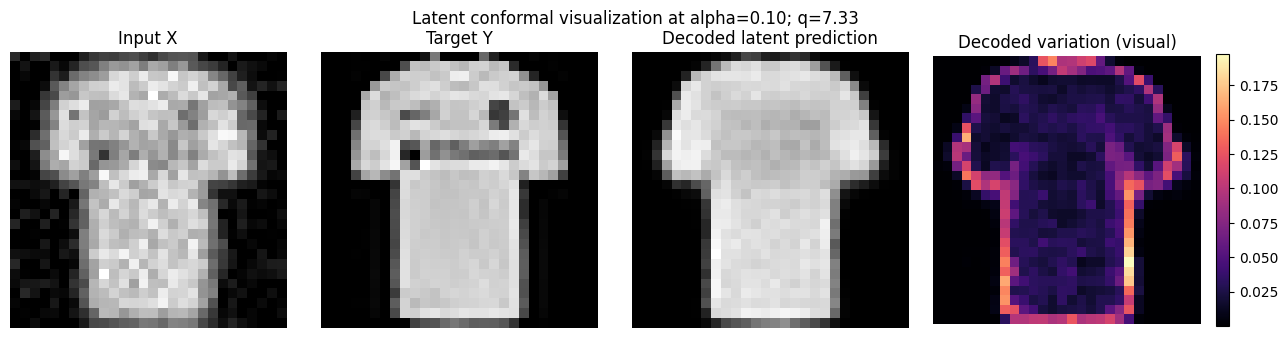

In [7]:
alpha_vis = 0.10
q_vis = split_conformal_quantile(scores_cal, alpha_vis)
eval_index = 0
x0, y0 = test_ds[0][eval_index:eval_index+1].to(DEVICE), test_ds[1][eval_index:eval_index+1].to(DEVICE)
with torch.no_grad(): z0 = predictor(x0).cpu().numpy()[0]
eigvals, eigvecs = np.linalg.eigh(cov)
order_eig = np.argsort(eigvals)[::-1]
# Boundary perturbations along the leading covariance directions.
perturbed = [z0]
for j in order_eig[:min(8, LATENT_DIM)]:
    delta = q_vis*np.sqrt(max(eigvals[j], 0))*eigvecs[:, j]
    perturbed.extend([z0+delta, z0-delta])
with torch.no_grad():
    decoded = autoencoder.decode(torch.tensor(np.stack(perturbed), dtype=torch.float32, device=DEVICE)).cpu().numpy()
center, spread = decoded[0], decoded[1:].std(axis=0)
center_img = center[0] if center.shape[0] == 1 else np.moveaxis(center, 0, -1)
spread_img = spread.mean(axis=0)
fig, ax = plt.subplots(1, 4, figsize=(13, 3.4))
def show_image(tensor):
    image = tensor.cpu().numpy()[0]
    return image[0] if image.shape[0] == 1 else np.moveaxis(image, 0, -1)
ax[0].imshow(show_image(x0), cmap='gray' if channels == 1 else None); ax[0].set_title('Input X')
ax[1].imshow(show_image(y0), cmap='gray' if channels == 1 else None); ax[1].set_title('Target Y')
ax[2].imshow(center_img, cmap='gray' if channels == 1 else None); ax[2].set_title('Decoded latent prediction')
im = ax[3].imshow(spread_img, cmap='magma'); ax[3].set_title('Decoded variation (visual)'); fig.colorbar(im, ax=ax[3], fraction=0.046)
for a in ax: a.axis('off')
plt.suptitle(f'Latent conformal visualization at alpha={alpha_vis:.2f}; q={q_vis:.2f}')
plt.tight_layout()
